# Run All Timepoint Models

**Task ** — Predict drug release at 24h / 48h / 72h (multi-output regression)
Models: XGBoost, Random Forest, Linear Regression

CV: Drug-level GroupKFold(n=10) — same drug never in both train and test.
Shared splits with run_all_models.ipynb for cross-task comparisons.

In [1]:
import sys
sys.path.insert(0, '.')

from drug_release_pipeline import (
    load_data, make_splits, verify_splits,
    run_tp_xgb, run_tp_rf, run_tp_linear,
    run_auc_xgb, run_auc_rf, run_auc_linear,
    compare_tp_models, compare_auc_models, wilcoxon_tests,
    TIMEPOINTS,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import shap
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

## 1. Load data

In [5]:
FILE_FORM = 'mp_dataset_processed_no_dupes.xlsx'
FILE_TIME = 'mp_dataset_processed_time_release_only.xlsx'

(X, _, _, y_timepoints, y_auc, y_class, _, _, _, aucs,
 drug_groups, _, _, feature_names) = load_data(FILE_FORM, FILE_TIME)

print(f'X shape              : {X.shape}')
print(f'y_timepoints shape   : {y_timepoints.shape}')
print(f'y_auc shape          : {y_auc.shape}')
print(f'drug_groups shape    : {drug_groups.shape}')
print(f'Unique drugs         : {len(set(drug_groups))}')
print(f'Feature names        : {feature_names}')
print(f'\ny_timepoints range   : [{y_timepoints.min():.3f}, {y_timepoints.max():.3f}]')
print(f'y_auc range          : [{y_auc.min():.3f}, {y_auc.max():.3f}]')

X shape              : (321, 11)
y_timepoints shape   : (321, 3)
y_auc shape          : (321,)
drug_groups_form     : (321,)
Unique drugs         : 88
Feature names        : ['Drug MW', 'Drug TPSA', 'Drug LogP', 'Polymer MW', 'LA/GA', 'Initial Drug-to-Polymer Ratio', 'Particle Size', 'Drug Loading Capacity', 'Drug Encapsulation Efficiency', 'Solubility Enhancer Concentration', 'Formulation Method Encoded']

y_timepoints range   : [0.000, 1.008]
y_auc range          : [1.605, 113.499]


In [6]:

outer_splits, inner_splits_per_outer = make_splits(drug_groups)
verify_splits(outer_splits, drug_groups)

# 2. Run XGB (SHAP computed automatically inside)
xgb_tp_results = run_tp_xgb(X, y_timepoints, outer_splits, inner_splits_per_outer)

# 3. Aggregate SHAP across folds for each timepoint
timepoint_labels = ["24h", "48h", "72h"]

shap_per_tp = []
X_all = np.concatenate(xgb_tp_results["shap_X_test"], axis=0)

for tp_i in range(3):
    shap_tp = np.concatenate(
        [fold_shap[tp_i] for fold_shap in xgb_tp_results["shap_values"]],
        axis=0
    )
    shap_per_tp.append(shap_tp)



[verify_splits] OK — 10 folds, 321 formulations, no drug leakage.

===== XGB-Timepoint | OUTER FOLD 1/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 9, 'learning_rate': 0.28570714885887566, 'n_estimators': 233, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'reg_alpha': 0.05808361216819946, 'reg_lambda': 0.8661761457749352}
  Best params: {'max_depth': 9, 'learning_rate': 0.28570714885887566, 'n_estimators': 233, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'reg_alpha': 0.05808361216819946, 'reg_lambda': 0.8661761457749352}
  1d: RMSE=0.2003  Corr=0.5555  AdjR²=-0.2090
  2d: RMSE=0.2220  Corr=0.4999  AdjR²=-0.1789
  3d: RMSE=0.2228  Corr=0.4874  AdjR²=-0.0919
  Overall — RMSE=0.2153  Corr=0.4602  p=4.49e-09

===== XGB-Timepoint | OUTER FOLD 2/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 15, 'learning_rate': 0.016348539297838638, 'n_estimators': 169, 'subsample': 0.8834641024663169, 'colsample_bytree': 0.9543505362399609, 'gamma': 0.23404450968498527, 'reg_alpha': 0.5574986200583372, 'reg_lambda': 0.23265021630938088}
  Best params: {'max_depth': 15, 'learning_rate': 0.016348539297838638, 'n_estimators': 169, 'subsample': 0.8834641024663169, 'colsample_bytree': 0.9543505362399609, 'gamma': 0.23404450968498527, 'reg_alpha': 0.5574986200583372, 'reg_lambda': 0.23265021630938088}
  1d: RMSE=0.1578  Corr=0.5672  AdjR²=-0.9339
  2d: RMSE=0.2049  Corr=0.5844  AdjR²=-0.9084
  3d: RMSE=0.2178  Corr=0.6854  AdjR²=-0.9363
  Overall — RMSE=0.1952  Corr=0.5356  p=3.16e-08

===== XGB-Timepoint | OUTER FOLD 3/10 =====


...

  Best params: {'max_depth': 15, 'learning_rate': 0.23952811212992034, 'n_estimators': 251, 'subsample': 0.688458041301826, 'colsample_bytree': 0.7166614013598864, 'gamma': 0.42194837493995097, 'reg_alpha': 0.007246638353600145, 'reg_lambda': 0.8061433577581774}
  Best params: {'max_depth': 15, 'learning_rate': 0.23952811212992034, 'n_estimators': 251, 'subsample': 0.688458041301826, 'colsample_bytree': 0.7166614013598864, 'gamma': 0.42194837493995097, 'reg_alpha': 0.007246638353600145, 'reg_lambda': 0.8061433577581774}
  1d: RMSE=0.2152  Corr=0.1836  AdjR²=-0.6870
  2d: RMSE=0.2557  Corr=0.1238  AdjR²=-0.7542
  3d: RMSE=0.2631  Corr=0.2047  AdjR²=-0.6367
  Overall — RMSE=0.2456  Corr=0.2892  p=5.71e-03

===== XGB-Timepoint | OUTER FOLD 9/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 16, 'learning_rate': 0.23451872154758055, 'n_estimators': 218, 'subsample': 0.7840567920958885, 'colsample_bytree': 0.6042526749602392, 'gamma': 0.3164539210357894, 'reg_alpha': 0.2916144790401682, 'reg_lambda': 0.29883277780688355}
  Best params: {'max_depth': 16, 'learning_rate': 0.23451872154758055, 'n_estimators': 218, 'subsample': 0.7840567920958885, 'colsample_bytree': 0.6042526749602392, 'gamma': 0.3164539210357894, 'reg_alpha': 0.2916144790401682, 'reg_lambda': 0.29883277780688355}
  1d: RMSE=0.2230  Corr=0.1765  AdjR²=-0.5692
  2d: RMSE=0.2408  Corr=0.2190  AdjR²=-0.5584
  3d: RMSE=0.2608  Corr=0.1901  AdjR²=-0.6167
  Overall — RMSE=0.2420  Corr=0.2407  p=2.23e-02

===== XGB-Timepoint | OUTER FOLD 10/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 15, 'learning_rate': 0.20134372351119076, 'n_estimators': 278, 'subsample': 0.7009958851787432, 'colsample_bytree': 0.9561375434553903, 'gamma': 0.2973986400156281, 'reg_alpha': 0.43792684075888016, 'reg_lambda': 0.21234536206545498}
  Best params: {'max_depth': 15, 'learning_rate': 0.20134372351119076, 'n_estimators': 278, 'subsample': 0.7009958851787432, 'colsample_bytree': 0.9561375434553903, 'gamma': 0.2973986400156281, 'reg_alpha': 0.43792684075888016, 'reg_lambda': 0.21234536206545498}
  1d: RMSE=0.1536  Corr=0.0298  AdjR²=-1.1652
  2d: RMSE=0.1970  Corr=-0.0965  AdjR²=-1.6434
  3d: RMSE=0.2106  Corr=-0.0490  AdjR²=-1.3076
  Overall — RMSE=0.1886  Corr=0.2268  p=3.16e-02

[XGB-Timepoint] Overall RMSE : 0.2069 ± 0.0411
Time             RMSE                 Corr                AdjR²        
--------------------------------------------------------------------
1d       0.1838 ± 0.0380   0.3199           -0.8919
2d       0.2128 ± 0.0434   0.3270           

In [7]:
# Run RF and Linear regression for timepoint prediction
rf_tp_results     = run_tp_rf(X, y_timepoints, outer_splits, inner_splits_per_outer)
linear_tp_results = run_tp_linear(X, y_timepoints, outer_splits, inner_splits_per_outer)

# ── Aggregate RF SHAP across folds ───────────────────────────────────────────
X_all_rf    = np.concatenate(rf_tp_results["shap_X_test"], axis=0)
shap_per_tp_rf = []
for tp_i in range(3):
    shap_tp = np.concatenate(
        [fold_shap[tp_i] for fold_shap in rf_tp_results["shap_values"]],
        axis=0
    )
    shap_per_tp_rf.append(shap_tp)


===== RF-Timepoint | OUTER FOLD 1/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'n_estimators': 112, 'max_depth': 11, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}
  Best params: {'n_estimators': 112, 'max_depth': 11, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}
  1d: RMSE=0.2121  Corr=0.2661  AdjR²=-0.3552
  2d: RMSE=0.2291  Corr=0.3987  AdjR²=-0.2555
  3d: RMSE=0.2264  Corr=0.5524  AdjR²=-0.1270
  Overall — RMSE=0.2226  Corr=0.4386  p=2.76e-08

===== RF-Timepoint | OUTER FOLD 2/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'n_estimators': 145, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}
  Best params: {'n_estimators': 145, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}
  1d: RMSE=0.1615  Corr=0.4151  AdjR²=-1.0252
  2d: RMSE=0.2068  Corr=0.5614  AdjR²=-0.9450
  3d: RMSE=0.2228  Corr=0.6423  AdjR²=-1.0270
  Overall — RMSE=0.1987  Corr=0.5151  p=1.27e-07

===== RF-Timepoint | OUTER FOLD 3/10 =====


...

  Best params: {'n_estimators': 104, 'max_depth': 12, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}
  Best params: {'n_estimators': 104, 'max_depth': 12, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}
  1d: RMSE=0.2104  Corr=0.2468  AdjR²=-0.6133
  2d: RMSE=0.2451  Corr=0.2920  AdjR²=-0.6114
  3d: RMSE=0.2603  Corr=0.3343  AdjR²=-0.6022
  Overall — RMSE=0.2395  Corr=0.3801  p=2.20e-04

===== RF-Timepoint | OUTER FOLD 9/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'n_estimators': 195, 'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}
  Best params: {'n_estimators': 195, 'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}
  1d: RMSE=0.2177  Corr=0.2777  AdjR²=-0.4961
  2d: RMSE=0.2384  Corr=0.2810  AdjR²=-0.5280
  3d: RMSE=0.2561  Corr=0.2726  AdjR²=-0.5590
  Overall — RMSE=0.2380  Corr=0.3052  p=3.44e-03

===== RF-Timepoint | OUTER FOLD 10/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'n_estimators': 167, 'max_depth': 13, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False}
  Best params: {'n_estimators': 167, 'max_depth': 13, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False}
  1d: RMSE=0.1569  Corr=-0.1480  AdjR²=-1.2591
  2d: RMSE=0.1857  Corr=-0.1471  AdjR²=-1.3506
  3d: RMSE=0.2171  Corr=-0.1746  AdjR²=-1.4525
  Overall — RMSE=0.1882  Corr=0.1312  p=2.18e-01

[RF-Timepoint] Overall RMSE : 0.2086 ± 0.0400
Time             RMSE                 Corr                AdjR²        
--------------------------------------------------------------------
1d       0.1854 ± 0.0387   0.2641           -0.9083
2d       0.2125 ± 0.0412   0.3205           -0.8566
3d       0.2251 ± 0.0442   0.3656           -0.7511

===== Linear-Timepoint | OUTER FOLD 1/10 =====
  1d: RMSE=0.2002  Corr=0.4097  AdjR²=-0.2073
  2d: RMSE=0.2246  Corr=0.3686  AdjR²=-0.2068
  3d: RMSE=0.2283  Corr=0.4463  

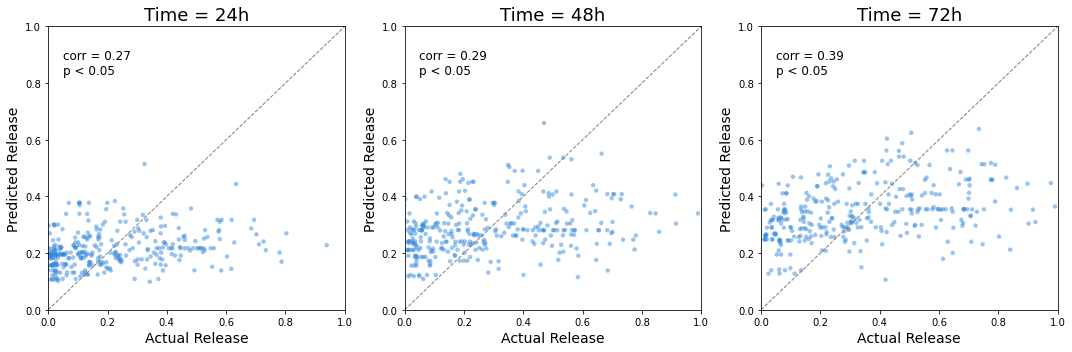

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

timepoint_labels = ["24h", "48h", "72h"]

for i, (ax, label) in enumerate(zip(axes, timepoint_labels)):
    
    # aggregate predicted and true across all folds
    y_true = np.concatenate([fold[:, i] for fold in xgb_tp_results["targets"]], axis=0)
    y_pred = np.concatenate([fold[:, i] for fold in xgb_tp_results["preds"]],   axis=0)
    
    corr, pval = pearsonr(y_true, y_pred)
    
    ax.scatter(y_true, y_pred, alpha=0.5, s=20, color="#378ADD", edgecolors="none")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Perfect prediction")
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Actual Release", fontsize=14)
    ax.set_ylabel("Predicted Release", fontsize=14)
    ax.set_title(f"Time = {label}", fontsize=18, fontweight="normal")
    ax.text(0.05, 0.92, f"corr = {corr:.2f}\np < 0.05",
            transform=ax.transAxes, fontsize=12,
            verticalalignment="top")
#    ax.text(-0.12, 1.02, ["a", "b", "c"][i], transform=ax.transAxes,
#            fontsize=12, fontweight="bold", va="top")

plt.tight_layout()
plt.savefig("hourly_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

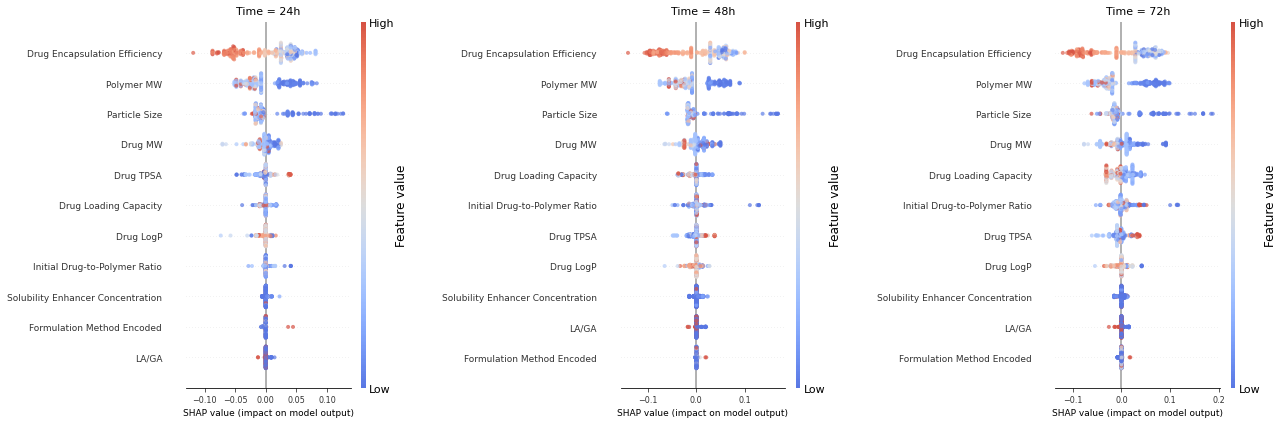

In [18]:
# 3. Aggregate SHAP across folds for each timepoint
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# ── Colormap ──────────────────────────────────────────────────────────────────
base_cmap  = mpl.colormaps['coolwarm']
light_cmap = LinearSegmentedColormap.from_list(
    'light_coolwarm', base_cmap(np.linspace(0.1, 0.9, 256))
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (ax, label) in enumerate(zip(axes, timepoint_labels)):
    plt.sca(ax)
    shap.summary_plot(
        shap_per_tp[i],
        X_all,
        feature_names=feature_names,
        show=False,
        plot_type="dot",
        cmap=light_cmap,
        plot_size=None,
        max_display=11,
        alpha=0.7,
    )
    ax.set_title(f"Time = {label}", fontsize=11, fontweight='normal', pad=8)
    ax.set_xlabel("SHAP value (impact on model output)", fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=8)
    # add panel label (a, b, c)
#    ax.text(-0.12, 1.02, ['a', 'b', 'c'][i], transform=ax.transAxes,
#           fontsize=12, fontweight='bold', va='top')

plt.tight_layout(w_pad=3)
plt.savefig("hourly_shap.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Generate & verify drug-level splits

In [3]:
outer_splits, inner_splits_per_outer = make_splits(drug_groups)
verify_splits(outer_splits, drug_groups)

[verify_splits] OK — 10 folds, 321 formulations, no drug leakage.


## 3. Task 1 — Timepoint prediction (24h / 48h / 72h)

In [4]:
results_tp_rf = run_tp_rf(X, y_timepoints, outer_splits, inner_splits_per_outer)


===== RF-Timepoint | OUTER FOLD 1/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'n_estimators': 112, 'max_depth': 11, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}
  Best params: {'n_estimators': 112, 'max_depth': 11, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}
  1d: RMSE=0.2121  Corr=0.2661  AdjR²=-0.3552
  2d: RMSE=0.2291  Corr=0.3987  AdjR²=-0.2555
  3d: RMSE=0.2264  Corr=0.5524  AdjR²=-0.1270
  Overall — RMSE=0.2226  Corr=0.4386  p=2.76e-08

===== RF-Timepoint | OUTER FOLD 2/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'n_estimators': 145, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}
  Best params: {'n_estimators': 145, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}
  1d: RMSE=0.1615  Corr=0.4151  AdjR²=-1.0252
  2d: RMSE=0.2068  Corr=0.5614  AdjR²=-0.9450
  3d: RMSE=0.2228  Corr=0.6423  AdjR²=-1.0270
  Overall — RMSE=0.1987  Corr=0.5151  p=1.27e-07

===== RF-Timepoint | OUTER FOLD 3/10 =====


...

  Best params: {'n_estimators': 104, 'max_depth': 12, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}
  Best params: {'n_estimators': 104, 'max_depth': 12, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}
  1d: RMSE=0.2104  Corr=0.2468  AdjR²=-0.6133
  2d: RMSE=0.2451  Corr=0.2920  AdjR²=-0.6114
  3d: RMSE=0.2603  Corr=0.3343  AdjR²=-0.6022
  Overall — RMSE=0.2395  Corr=0.3801  p=2.20e-04

===== RF-Timepoint | OUTER FOLD 9/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'n_estimators': 195, 'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}
  Best params: {'n_estimators': 195, 'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}
  1d: RMSE=0.2177  Corr=0.2777  AdjR²=-0.4961
  2d: RMSE=0.2384  Corr=0.2810  AdjR²=-0.5280
  3d: RMSE=0.2561  Corr=0.2726  AdjR²=-0.5590
  Overall — RMSE=0.2380  Corr=0.3052  p=3.44e-03

===== RF-Timepoint | OUTER FOLD 10/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'n_estimators': 167, 'max_depth': 13, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False}
  Best params: {'n_estimators': 167, 'max_depth': 13, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False}
  1d: RMSE=0.1569  Corr=-0.1480  AdjR²=-1.2591
  2d: RMSE=0.1857  Corr=-0.1471  AdjR²=-1.3506
  3d: RMSE=0.2171  Corr=-0.1746  AdjR²=-1.4525
  Overall — RMSE=0.1882  Corr=0.1312  p=2.18e-01

[RF-Timepoint] Overall RMSE : 0.2086 ± 0.0400
Time             RMSE                 Corr                AdjR²        
--------------------------------------------------------------------
1d       0.1854 ± 0.0387   0.2641           -0.9083
2d       0.2125 ± 0.0412   0.3205           -0.8566
3d       0.2251 ± 0.0442   0.3656           -0.7511


In [5]:
results_tp_xgb = run_tp_xgb(X, y_timepoints, outer_splits, inner_splits_per_outer)


===== XGB-Timepoint | OUTER FOLD 1/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 9, 'learning_rate': 0.28570714885887566, 'n_estimators': 233, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'reg_alpha': 0.05808361216819946, 'reg_lambda': 0.8661761457749352}
  Best params: {'max_depth': 9, 'learning_rate': 0.28570714885887566, 'n_estimators': 233, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'reg_alpha': 0.05808361216819946, 'reg_lambda': 0.8661761457749352}
  1d: RMSE=0.2003  Corr=0.5555  AdjR²=-0.2090
  2d: RMSE=0.2220  Corr=0.4999  AdjR²=-0.1789
  3d: RMSE=0.2228  Corr=0.4874  AdjR²=-0.0919
  Overall — RMSE=0.2153  Corr=0.4602  p=4.49e-09

===== XGB-Timepoint | OUTER FOLD 2/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 15, 'learning_rate': 0.016348539297838638, 'n_estimators': 169, 'subsample': 0.8834641024663169, 'colsample_bytree': 0.9543505362399609, 'gamma': 0.23404450968498527, 'reg_alpha': 0.5574986200583372, 'reg_lambda': 0.23265021630938088}
  Best params: {'max_depth': 15, 'learning_rate': 0.016348539297838638, 'n_estimators': 169, 'subsample': 0.8834641024663169, 'colsample_bytree': 0.9543505362399609, 'gamma': 0.23404450968498527, 'reg_alpha': 0.5574986200583372, 'reg_lambda': 0.23265021630938088}
  1d: RMSE=0.1578  Corr=0.5672  AdjR²=-0.9339
  2d: RMSE=0.2049  Corr=0.5844  AdjR²=-0.9084
  3d: RMSE=0.2178  Corr=0.6854  AdjR²=-0.9363
  Overall — RMSE=0.1952  Corr=0.5356  p=3.16e-08

===== XGB-Timepoint | OUTER FOLD 3/10 =====


...

  Best params: {'max_depth': 15, 'learning_rate': 0.23952811212992034, 'n_estimators': 251, 'subsample': 0.688458041301826, 'colsample_bytree': 0.7166614013598864, 'gamma': 0.42194837493995097, 'reg_alpha': 0.007246638353600145, 'reg_lambda': 0.8061433577581774}
  Best params: {'max_depth': 15, 'learning_rate': 0.23952811212992034, 'n_estimators': 251, 'subsample': 0.688458041301826, 'colsample_bytree': 0.7166614013598864, 'gamma': 0.42194837493995097, 'reg_alpha': 0.007246638353600145, 'reg_lambda': 0.8061433577581774}
  1d: RMSE=0.2152  Corr=0.1836  AdjR²=-0.6870
  2d: RMSE=0.2557  Corr=0.1238  AdjR²=-0.7542
  3d: RMSE=0.2631  Corr=0.2047  AdjR²=-0.6367
  Overall — RMSE=0.2456  Corr=0.2892  p=5.71e-03

===== XGB-Timepoint | OUTER FOLD 9/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 16, 'learning_rate': 0.23451872154758055, 'n_estimators': 218, 'subsample': 0.7840567920958885, 'colsample_bytree': 0.6042526749602392, 'gamma': 0.3164539210357894, 'reg_alpha': 0.2916144790401682, 'reg_lambda': 0.29883277780688355}
  Best params: {'max_depth': 16, 'learning_rate': 0.23451872154758055, 'n_estimators': 218, 'subsample': 0.7840567920958885, 'colsample_bytree': 0.6042526749602392, 'gamma': 0.3164539210357894, 'reg_alpha': 0.2916144790401682, 'reg_lambda': 0.29883277780688355}
  1d: RMSE=0.2230  Corr=0.1765  AdjR²=-0.5692
  2d: RMSE=0.2408  Corr=0.2190  AdjR²=-0.5584
  3d: RMSE=0.2608  Corr=0.1901  AdjR²=-0.6167
  Overall — RMSE=0.2420  Corr=0.2407  p=2.23e-02

===== XGB-Timepoint | OUTER FOLD 10/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 15, 'learning_rate': 0.20134372351119076, 'n_estimators': 278, 'subsample': 0.7009958851787432, 'colsample_bytree': 0.9561375434553903, 'gamma': 0.2973986400156281, 'reg_alpha': 0.43792684075888016, 'reg_lambda': 0.21234536206545498}
  Best params: {'max_depth': 15, 'learning_rate': 0.20134372351119076, 'n_estimators': 278, 'subsample': 0.7009958851787432, 'colsample_bytree': 0.9561375434553903, 'gamma': 0.2973986400156281, 'reg_alpha': 0.43792684075888016, 'reg_lambda': 0.21234536206545498}
  1d: RMSE=0.1536  Corr=0.0298  AdjR²=-1.1652
  2d: RMSE=0.1970  Corr=-0.0965  AdjR²=-1.6434
  3d: RMSE=0.2106  Corr=-0.0490  AdjR²=-1.3076
  Overall — RMSE=0.1886  Corr=0.2268  p=3.16e-02

[XGB-Timepoint] Overall RMSE : 0.2069 ± 0.0411
Time             RMSE                 Corr                AdjR²        
--------------------------------------------------------------------
1d       0.1838 ± 0.0380   0.3199           -0.8919
2d       0.2128 ± 0.0434   0.3270           

In [6]:
results_tp_linear = run_tp_linear(X, y_timepoints, outer_splits, inner_splits_per_outer)


===== Linear-Timepoint | OUTER FOLD 1/10 =====
  1d: RMSE=0.2002  Corr=0.4097  AdjR²=-0.2073
  2d: RMSE=0.2246  Corr=0.3686  AdjR²=-0.2068
  3d: RMSE=0.2283  Corr=0.4463  AdjR²=-0.1457
  Overall — RMSE=0.2180  Corr=0.4212  p=1.09e-07

===== Linear-Timepoint | OUTER FOLD 2/10 =====
  1d: RMSE=0.1701  Corr=0.0854  AdjR²=-1.2467
  2d: RMSE=0.2167  Corr=0.1730  AdjR²=-1.1341
  3d: RMSE=0.2368  Corr=0.2307  AdjR²=-1.2901
  Overall — RMSE=0.2097  Corr=0.2290  p=2.73e-02

===== Linear-Timepoint | OUTER FOLD 3/10 =====
  1d: RMSE=0.2679  Corr=0.2896  AdjR²=-0.8237
  2d: RMSE=0.3052  Corr=0.2588  AdjR²=-1.0056
  3d: RMSE=0.3152  Corr=0.3057  AdjR²=-0.9185
  Overall — RMSE=0.2968  Corr=0.3579  p=4.28e-04

===== Linear-Timepoint | OUTER FOLD 4/10 =====
  1d: RMSE=0.1640  Corr=0.3448  AdjR²=-0.8221
  2d: RMSE=0.1955  Corr=0.3254  AdjR²=-0.6519
  3d: RMSE=0.2185  Corr=0.3389  AdjR²=-0.6219
  Overall — RMSE=0.1940  Corr=0.3904  p=1.42e-04

===== Linear-Timepoint | OUTER FOLD 5/10 =====
  1d: RMSE=0

## 4. Task 2 — AUC prediction

In [7]:
results_auc_xgb = run_auc_xgb(X, y_auc, outer_splits, inner_splits_per_outer)


===== XGB-AUC | OUTER FOLD 1/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 18, 'learning_rate': 0.010227668149964965, 'n_estimators': 140, 'subsample': 0.8340141875903644, 'colsample_bytree': 0.8114482741503551, 'gamma': 3.0444838811990063, 'reg_alpha': 0.8312508712532083, 'reg_lambda': 0.8627121320322839}
  Best params: {'max_depth': 18, 'learning_rate': 0.010227668149964965, 'n_estimators': 140, 'subsample': 0.8340141875903644, 'colsample_bytree': 0.8114482741503551, 'gamma': 3.0444838811990063, 'reg_alpha': 0.8312508712532083, 'reg_lambda': 0.8627121320322839}
  RMSE=13.8110  R²=-1.9400  AdjR²=-2.8141  Corr=0.2336  p=1.06e-01

===== XGB-AUC | OUTER FOLD 2/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 19, 'learning_rate': 0.013391050133703493, 'n_estimators': 83, 'subsample': 0.6021038138988754, 'colsample_bytree': 0.6462051695180671, 'gamma': 4.7161292839632045, 'reg_alpha': 0.35905419845568415, 'reg_lambda': 0.742279198534552}
  Best params: {'max_depth': 19, 'learning_rate': 0.013391050133703493, 'n_estimators': 83, 'subsample': 0.6021038138988754, 'colsample_bytree': 0.6462051695180671, 'gamma': 4.7161292839632045, 'reg_alpha': 0.35905419845568415, 'reg_lambda': 0.742279198534552}
  RMSE=9.1344  R²=-4.3017  AdjR²=-7.3712  Corr=-0.4932  p=4.82e-03

===== XGB-AUC | OUTER FOLD 3/10 =====


...

  Best params: {'max_depth': 8, 'learning_rate': 0.010898506578762577, 'n_estimators': 51, 'subsample': 0.7615968118217903, 'colsample_bytree': 0.5828916090820624, 'gamma': 2.03403879083853, 'reg_alpha': 0.197644511572416, 'reg_lambda': 0.2416086391486444}
  Best params: {'max_depth': 8, 'learning_rate': 0.010898506578762577, 'n_estimators': 51, 'subsample': 0.7615968118217903, 'colsample_bytree': 0.5828916090820624, 'gamma': 2.03403879083853, 'reg_alpha': 0.197644511572416, 'reg_lambda': 0.2416086391486444}
  RMSE=11.5312  R²=-0.1648  AdjR²=-0.8766  Corr=-0.2227  p=2.37e-01

===== XGB-AUC | OUTER FOLD 9/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 19, 'learning_rate': 0.12439043162930032, 'n_estimators': 259, 'subsample': 0.700500115015366, 'colsample_bytree': 0.6497763818091333, 'gamma': 2.0476619225817903, 'reg_alpha': 0.6521937986217918, 'reg_lambda': 0.8987913462461085}
  Best params: {'max_depth': 19, 'learning_rate': 0.12439043162930032, 'n_estimators': 259, 'subsample': 0.700500115015366, 'colsample_bytree': 0.6497763818091333, 'gamma': 2.0476619225817903, 'reg_alpha': 0.6521937986217918, 'reg_lambda': 0.8987913462461085}
  RMSE=15.3008  R²=-0.4317  AdjR²=-1.3066  Corr=-0.2027  p=2.83e-01

===== XGB-AUC | OUTER FOLD 10/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 9, 'learning_rate': 0.012326531792709835, 'n_estimators': 94, 'subsample': 0.5961070245308178, 'colsample_bytree': 0.7559946937005537, 'gamma': 2.2663676821427727, 'reg_alpha': 0.9022411600789247, 'reg_lambda': 0.8606075685928408}
  Best params: {'max_depth': 9, 'learning_rate': 0.012326531792709835, 'n_estimators': 94, 'subsample': 0.5961070245308178, 'colsample_bytree': 0.7559946937005537, 'gamma': 2.2663676821427727, 'reg_alpha': 0.9022411600789247, 'reg_lambda': 0.8606075685928408}
  RMSE=14.7753  R²=-0.0058  AdjR²=-0.6205  Corr=0.1546  p=4.15e-01

[XGB-AUC] RMSE   : 15.4781 ± 8.2474
[XGB-AUC] Adj R² : -2.1698 ± 1.9709
[XGB-AUC] Corr   : -0.0896 ± 0.2184


In [ ]:
results_auc_rf = run_auc_rf(X, y_auc, outer_splits, inner_splits_per_outer)

In [ ]:
results_auc_linear = run_auc_linear(X, y_auc, outer_splits, inner_splits_per_outer)

## 5. Compare models

In [ ]:
all_tp_results = {
    'XGB-Timepoint'    : results_tp_xgb,
    'RF-Timepoint'     : results_tp_rf,
    'Linear-Timepoint' : results_tp_linear,
}

df_tp = compare_tp_models(all_tp_results)

In [ ]:
all_auc_results = {
    'XGB-AUC'    : results_auc_xgb,
    'RF-AUC'     : results_auc_rf,
    'Linear-AUC' : results_auc_linear,
}

df_auc = compare_auc_models(all_auc_results)

## 6. Wilcoxon tests

In [ ]:
# Timepoint — overall RMSE
wilcoxon_tests(all_tp_results, metric='rmse')

# Per timepoint
for t in TIMEPOINTS:
    wilcoxon_tests(all_tp_results, metric=f'rmse_{t}d')

In [ ]:
# AUC — overall RMSE and adj R²
wilcoxon_tests(all_auc_results, metric='rmse')
wilcoxon_tests(all_auc_results, metric='adj_r2')

## 7. Plots — Task 1 (Timepoint)

In [ ]:
# Predicted vs actual scatter — XGB timepoint (best model)
all_preds   = np.vstack(results_tp_xgb['preds'])
all_targets = np.vstack(results_tp_xgb['targets'])

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, t in enumerate(TIMEPOINTS):
    ax = axes[i]
    sns.scatterplot(x=all_targets[:, i], y=all_preds[:, i],
                    alpha=0.5, edgecolor=None, s=50, ax=ax)
    lims = [min(all_targets[:, i].min(), all_preds[:, i].min()),
            max(all_targets[:, i].max(), all_preds[:, i].max())]
    ax.plot(lims, lims, 'k:', linewidth=2, label='Perfect prediction')
    corr, pval = pearsonr(all_targets[:, i], all_preds[:, i])
    ax.text(0.05, 0.95, f'r = {corr:.2f}\np = {pval:.2e}',
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel('Actual Release', fontsize=13)
    ax.set_ylabel('Predicted Release', fontsize=13)
    ax.set_title(f'Time = {t*24}h', fontsize=14)
    ax.legend(loc='lower right')

plt.suptitle('XGB Timepoint — Predicted vs Actual', fontsize=14)
plt.tight_layout()
plt.savefig('tp_xgb_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# RMSE boxplot per timepoint across folds — all models
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

colors = {'XGB-Timepoint': 'steelblue', 'RF-Timepoint': 'salmon', 'Linear-Timepoint': 'mediumpurple'}

for i, t in enumerate(TIMEPOINTS):
    ax = axes[i]
    data   = [res['rmse_per_tp'][t] for res in all_tp_results.values()]
    labels = list(all_tp_results.keys())
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, label in zip(bp['boxes'], labels):
        patch.set_facecolor(colors[label])
        patch.set_alpha(0.7)
    ax.set_xticklabels([l.replace('-Timepoint', '') for l in labels], fontsize=10)
    ax.set_title(f'Time = {t*24}h', fontsize=13)
    ax.set_ylabel('RMSE', fontsize=11)

plt.suptitle('RMSE distribution across folds — Timepoint models', fontsize=13)
plt.tight_layout()
plt.savefig('tp_rmse_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Plots — Task 2 (AUC)

In [ ]:
# Predicted vs actual scatter — XGB AUC
all_true = np.concatenate(results_auc_xgb['targets'])
all_pred = np.concatenate(results_auc_xgb['preds'])

sns.set_style('whitegrid')
plt.figure(figsize=(6, 6), dpi=120)
sns.scatterplot(x=all_true, y=all_pred, color='steelblue',
                alpha=0.6, edgecolor='white', s=50)
y_min, y_max = all_true.min(), all_true.max()
plt.plot([y_min, y_max], [y_min, y_max], '--', linewidth=2, color='black')
r, p = pearsonr(all_true, all_pred)
plt.text(0.05, 0.95, f'r = {r:.2f}\np = {p:.2e}',
         transform=plt.gca().transAxes, fontsize=12, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.xlabel('True AUC of Drug Release', fontsize=14)
plt.ylabel('Predicted AUC of Drug Release', fontsize=14)
plt.title('XGB-AUC — Predicted vs Actual', fontsize=13)
plt.tight_layout()
plt.savefig('auc_xgb_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# RMSE boxplot across folds — all AUC models
fig, ax = plt.subplots(figsize=(7, 5))
data   = [res['rmse'] for res in all_auc_results.values()]
labels = list(all_auc_results.keys())
colors_auc = ['steelblue', 'salmon', 'mediumpurple']
bp = ax.boxplot(data, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], colors_auc):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_xticklabels([l.replace('-AUC', '') for l in labels], fontsize=11)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('RMSE distribution across folds — AUC models', fontsize=13)
plt.tight_layout()
plt.savefig('auc_rmse_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. SHAP — Task 1 (XGB Timepoint)

In [ ]:
base_cmap  = cm.get_cmap('coolwarm')
light_cmap = LinearSegmentedColormap.from_list(
    'light_coolwarm', base_cmap(np.linspace(0.1, 0.9, 256))
)

all_X_test = np.vstack(results_tp_xgb['shap_X_test'])

for i, t in enumerate(TIMEPOINTS):
    shap_for_tp = np.vstack([
        fold_shap[i] for fold_shap in results_tp_xgb['shap_values']
        if fold_shap is not None
    ])
    plt.figure()
    shap.summary_plot(shap_for_tp, all_X_test,
                      feature_names=feature_names, show=False, cmap=light_cmap)
    plt.title(f'SHAP — XGB Timepoint — {t*24}h', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'shap_tp_xgb_{t*24}h.png', dpi=300, bbox_inches='tight')
    plt.show()

## 10. SHAP — Task 2 (XGB AUC)

In [ ]:
combined_shap = np.concatenate([
    sv for sv in results_auc_xgb['shap_values'] if sv is not None
], axis=0)
combined_X = np.concatenate(results_auc_xgb['shap_X_test'], axis=0)

plt.figure()
shap.summary_plot(combined_shap, combined_X,
                  feature_names=feature_names,
                  plot_type='dot', cmap=light_cmap, show=False)
ax = plt.gca()
ax.grid(True, which='both', axis='x', linestyle='--')
ax.set_axisbelow(True)
plt.title('SHAP — XGB AUC', fontsize=13)
plt.tight_layout()
plt.savefig('shap_auc_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Save results

In [ ]:
df_tp.to_csv('all_tp_models_metrics.csv', index=False)
df_auc.to_csv('all_auc_models_metrics.csv', index=False)

# Save predictions for each model
for name, res in {**all_tp_results, **all_auc_results}.items():
    rows = []
    for fold_i, (preds, targets) in enumerate(zip(res['preds'], res['targets']), 1):
        preds   = np.array(preds)
        targets = np.array(targets)
        if preds.ndim == 1:
            for p, t in zip(preds, targets):
                rows.append({'model': name, 'fold': fold_i, 'y_pred': p, 'y_true': t})
        else:
            for p_row, t_row in zip(preds, targets):
                row = {'model': name, 'fold': fold_i}
                for j, tp in enumerate(TIMEPOINTS):
                    row[f'y_pred_{tp}d'] = p_row[j]
                    row[f'y_true_{tp}d'] = t_row[j]
                rows.append(row)
    pd.DataFrame(rows).to_csv(f"{name.replace(' ', '_')}_preds.csv", index=False)

print('Saved all_tp_models_metrics.csv, all_auc_models_metrics.csv, and per-model prediction CSVs.')